<a href="https://colab.research.google.com/github/sonjoy1s/ML/blob/main/Cyber_Security_Attack_Using_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [30]:
df = pd.read_csv("/content/cyber_attack_dataset_100000.csv")
df

,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
0,1,8605,418,631,TCP,0,DDoS
1,1,499,148,131,UDP,0,PortScan
2,10,370,160,105,UDP,0,PortScan
3,2,5138,320,666,TCP,0,DDoS
4,36,524,467,58,UDP,10,BruteForce
...,...,...,...,...,...,...,...
99995,10,380,41,143,TCP,0,PortScan
99996,2,153,146,85,TCP,0,PortScan
99997,37,161,114,61,UDP,10,BruteForce
99998,4,142,69,73,TCP,0,PortScan


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   duration       100000 non-null  int64 
 1   src_bytes      100000 non-null  int64 
 2   dst_bytes      100000 non-null  int64 
 3   packet_count   100000 non-null  int64 
 4   protocol       100000 non-null  object
 5   failed_logins  100000 non-null  int64 
 6   attack_type    100000 non-null  object
dtypes: int64(5), object(2)
memory usage: 5.3+ MB


In [32]:
df.columns

Index(['duration', 'src_bytes', 'dst_bytes', 'packet_count', 'protocol',
       'failed_logins', 'attack_type'],
      dtype='object')

In [33]:
df.shape[0]

100000

In [34]:
df.shape[1]

7

In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,100000.0,16.46272,15.632207,1.0,4.0,10.0,28.0,60.0
src_bytes,100000.0,2219.62870,2751.142410,50.0,341.0,781.0,3024.0,10000.0
dst_bytes,100000.0,426.17103,466.528205,20.0,131.0,256.0,458.0,2000.0
packet_count,100000.0,202.55077,249.729802,5.0,37.0,87.0,257.0,1000.0
failed_logins,100000.0,1.63052,3.045577,0.0,0.0,0.0,3.0,10.0


In [36]:
df.isna().sum()

,0
duration,0
src_bytes,0
dst_bytes,0
packet_count,0
protocol,0
failed_logins,0
attack_type,0


In [37]:
df.nunique()

,0
duration,60
src_bytes,9739
dst_bytes,1981
packet_count,996
protocol,2
failed_logins,9
attack_type,4


In [81]:
df.duplicated().sum()

np.int64(1)

In [38]:
df.head()

,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
0,1,8605,418,631,TCP,0,DDoS
1,1,499,148,131,UDP,0,PortScan
2,10,370,160,105,UDP,0,PortScan
3,2,5138,320,666,TCP,0,DDoS
4,36,524,467,58,UDP,10,BruteForce


In [39]:
df['attack_type'].unique()

array(['DDoS', 'PortScan', 'BruteForce', 'Normal'], dtype=object)

In [40]:
le = LabelEncoder()
df['attack_type'] = le.fit_transform(df['attack_type'])
df

,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
0,1,8605,418,631,TCP,0,1
1,1,499,148,131,UDP,0,3
2,10,370,160,105,UDP,0,3
3,2,5138,320,666,TCP,0,1
4,36,524,467,58,UDP,10,0
...,...,...,...,...,...,...,...
99995,10,380,41,143,TCP,0,3
99996,2,153,146,85,TCP,0,3
99997,37,161,114,61,UDP,10,0
99998,4,142,69,73,TCP,0,3


In [59]:
import pandas as pd

df.corr(numeric_only=True)

,duration,src_bytes,dst_bytes,packet_count,failed_logins,attack_type
duration,1.000000,-0.357621,0.484247,-0.541066,0.293586,-0.209518
src_bytes,-0.357621,1.000000,-0.038516,0.698661,-0.325359,-0.234630
dst_bytes,0.484247,-0.038516,1.000000,-0.279961,-0.175321,0.067639
packet_count,-0.541066,0.698661,-0.279961,1.000000,-0.316262,-0.074087
failed_logins,0.293586,-0.325359,-0.175321,-0.316262,1.000000,-0.717309
attack_type,-0.209518,-0.234630,0.067639,-0.074087,-0.717309,1.000000


In [41]:
X = df.drop(columns=['attack_type'],axis=1)
y = df['attack_type']

In [42]:
numerical_cols = X.select_dtypes(include=np.number).columns
print(numerical_cols)

categorical_cols = X.select_dtypes(include='object').columns
print(categorical_cols)

Index(['duration', 'src_bytes', 'dst_bytes', 'packet_count', 'failed_logins'], dtype='object')
Index(['protocol'], dtype='object')


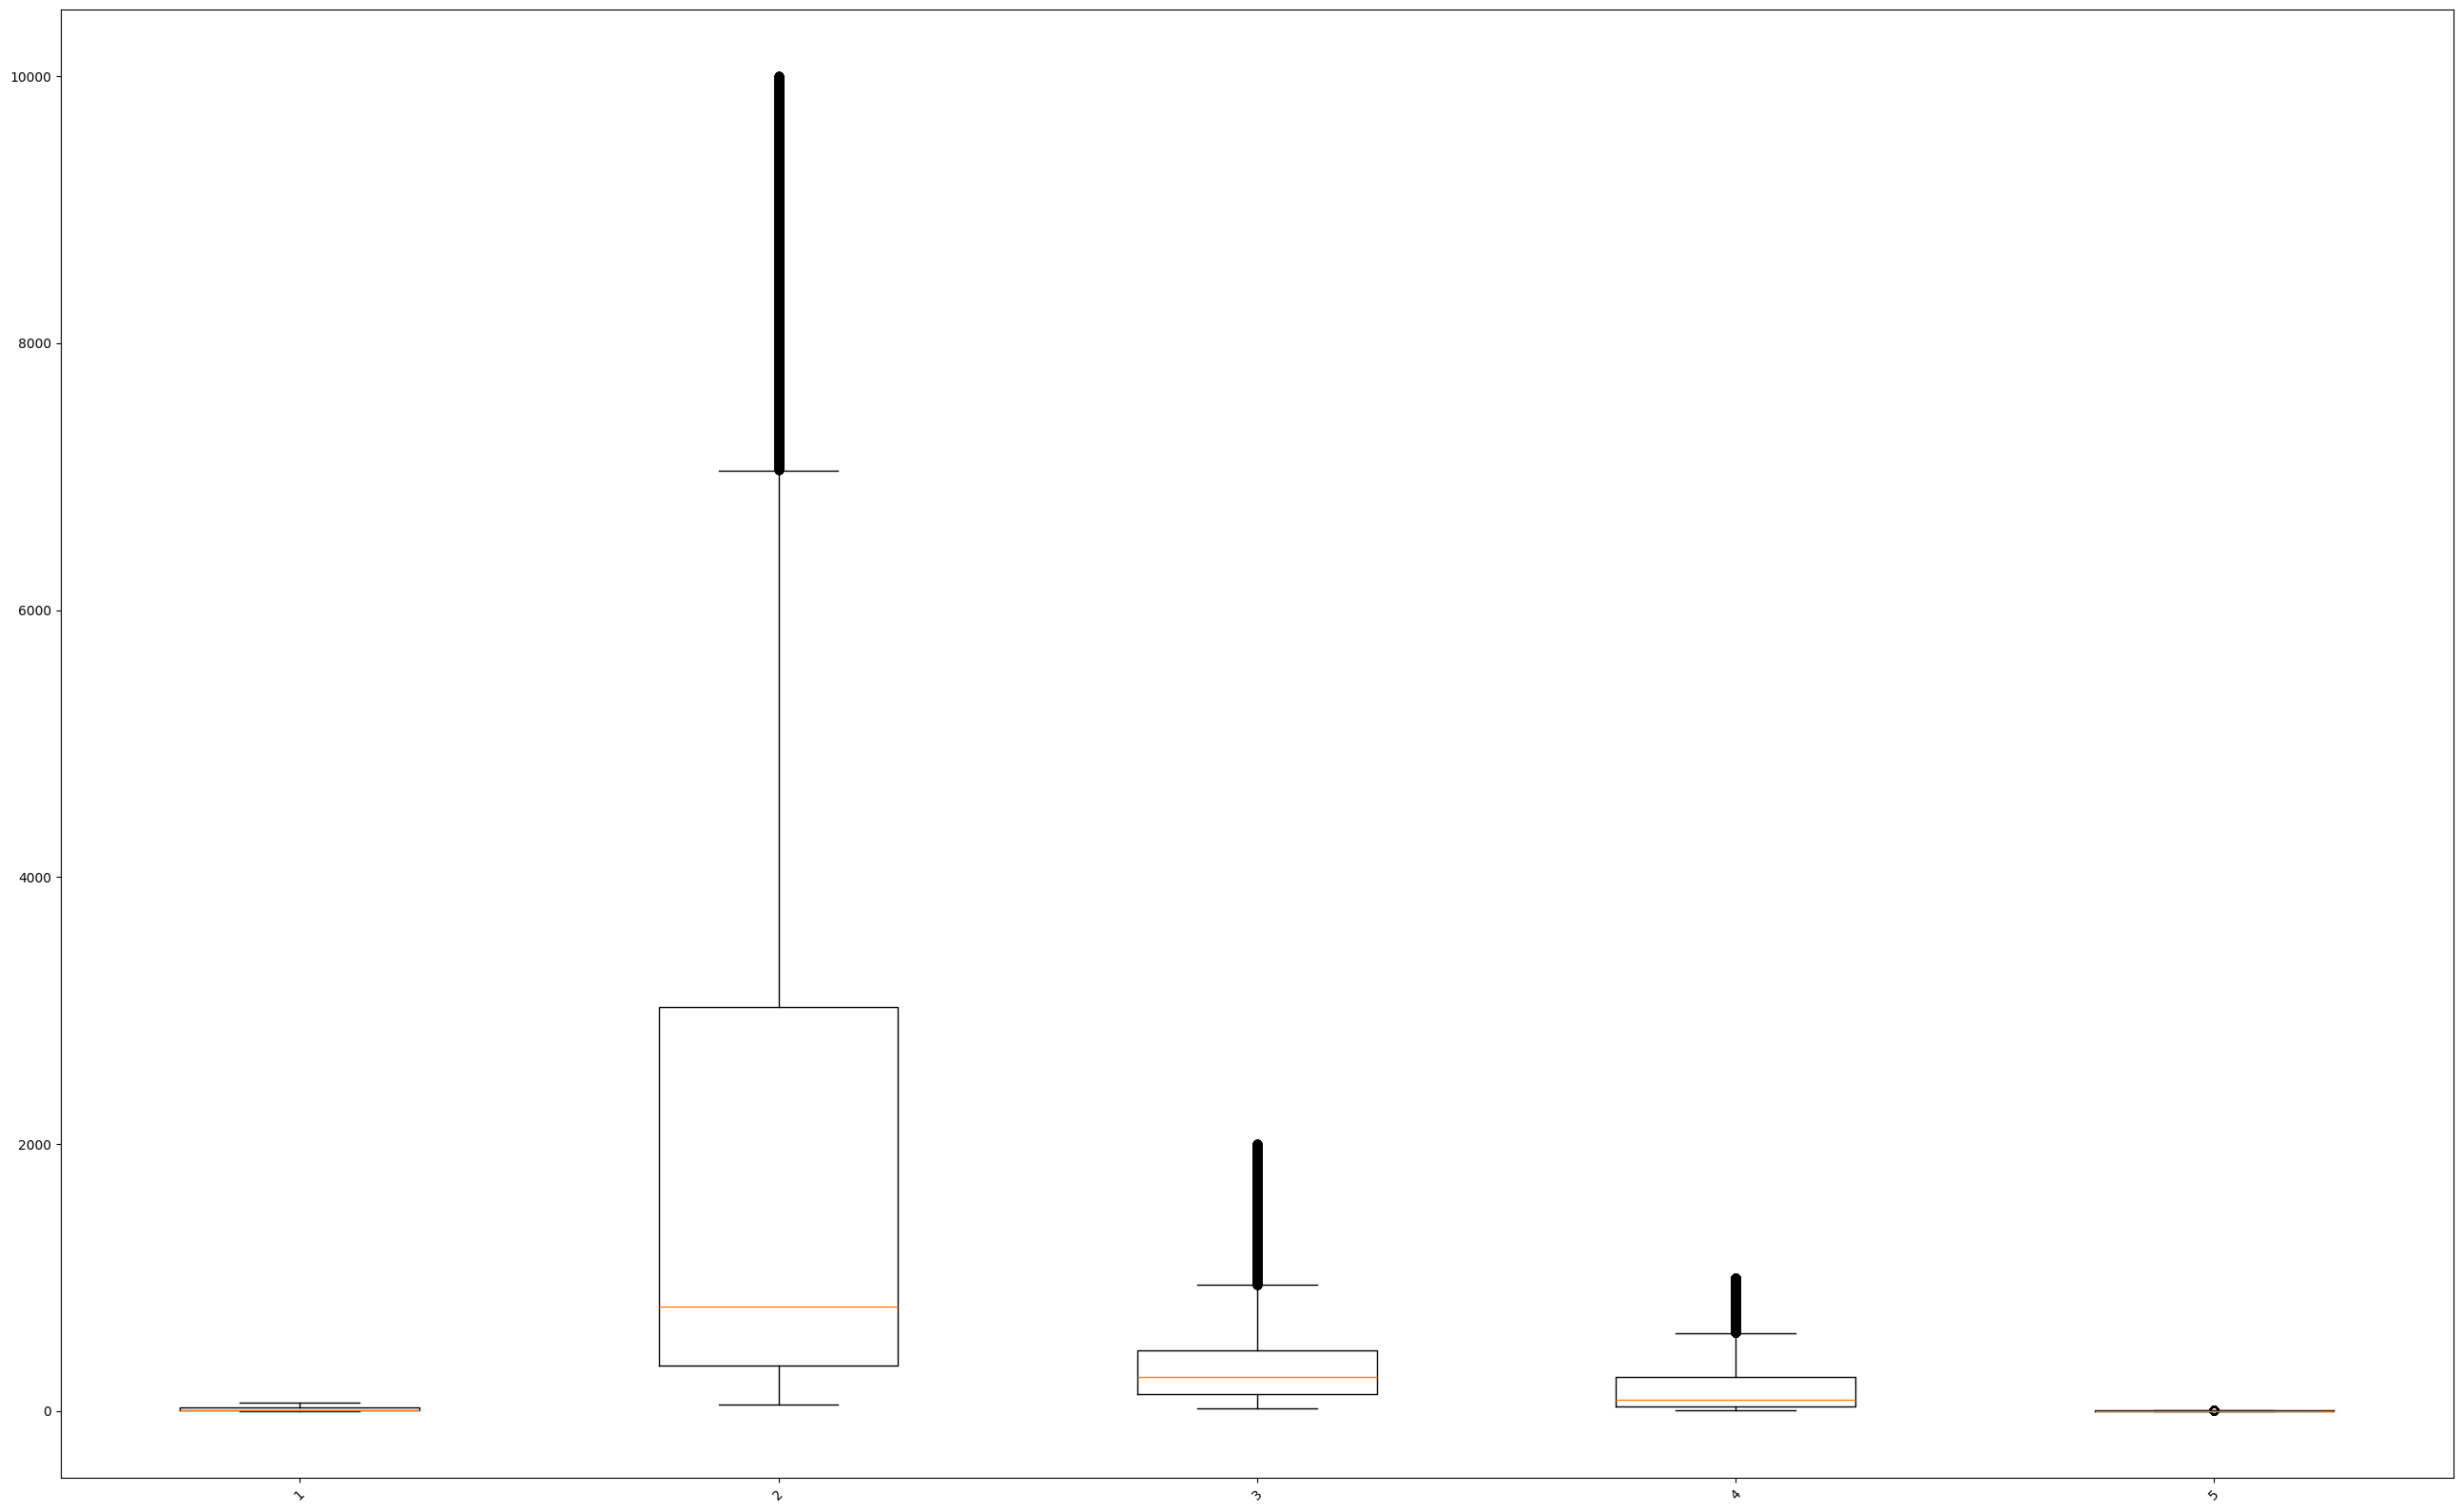

In [43]:
plt.figure(figsize=(26,16))
plt.boxplot(df[numerical_cols])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

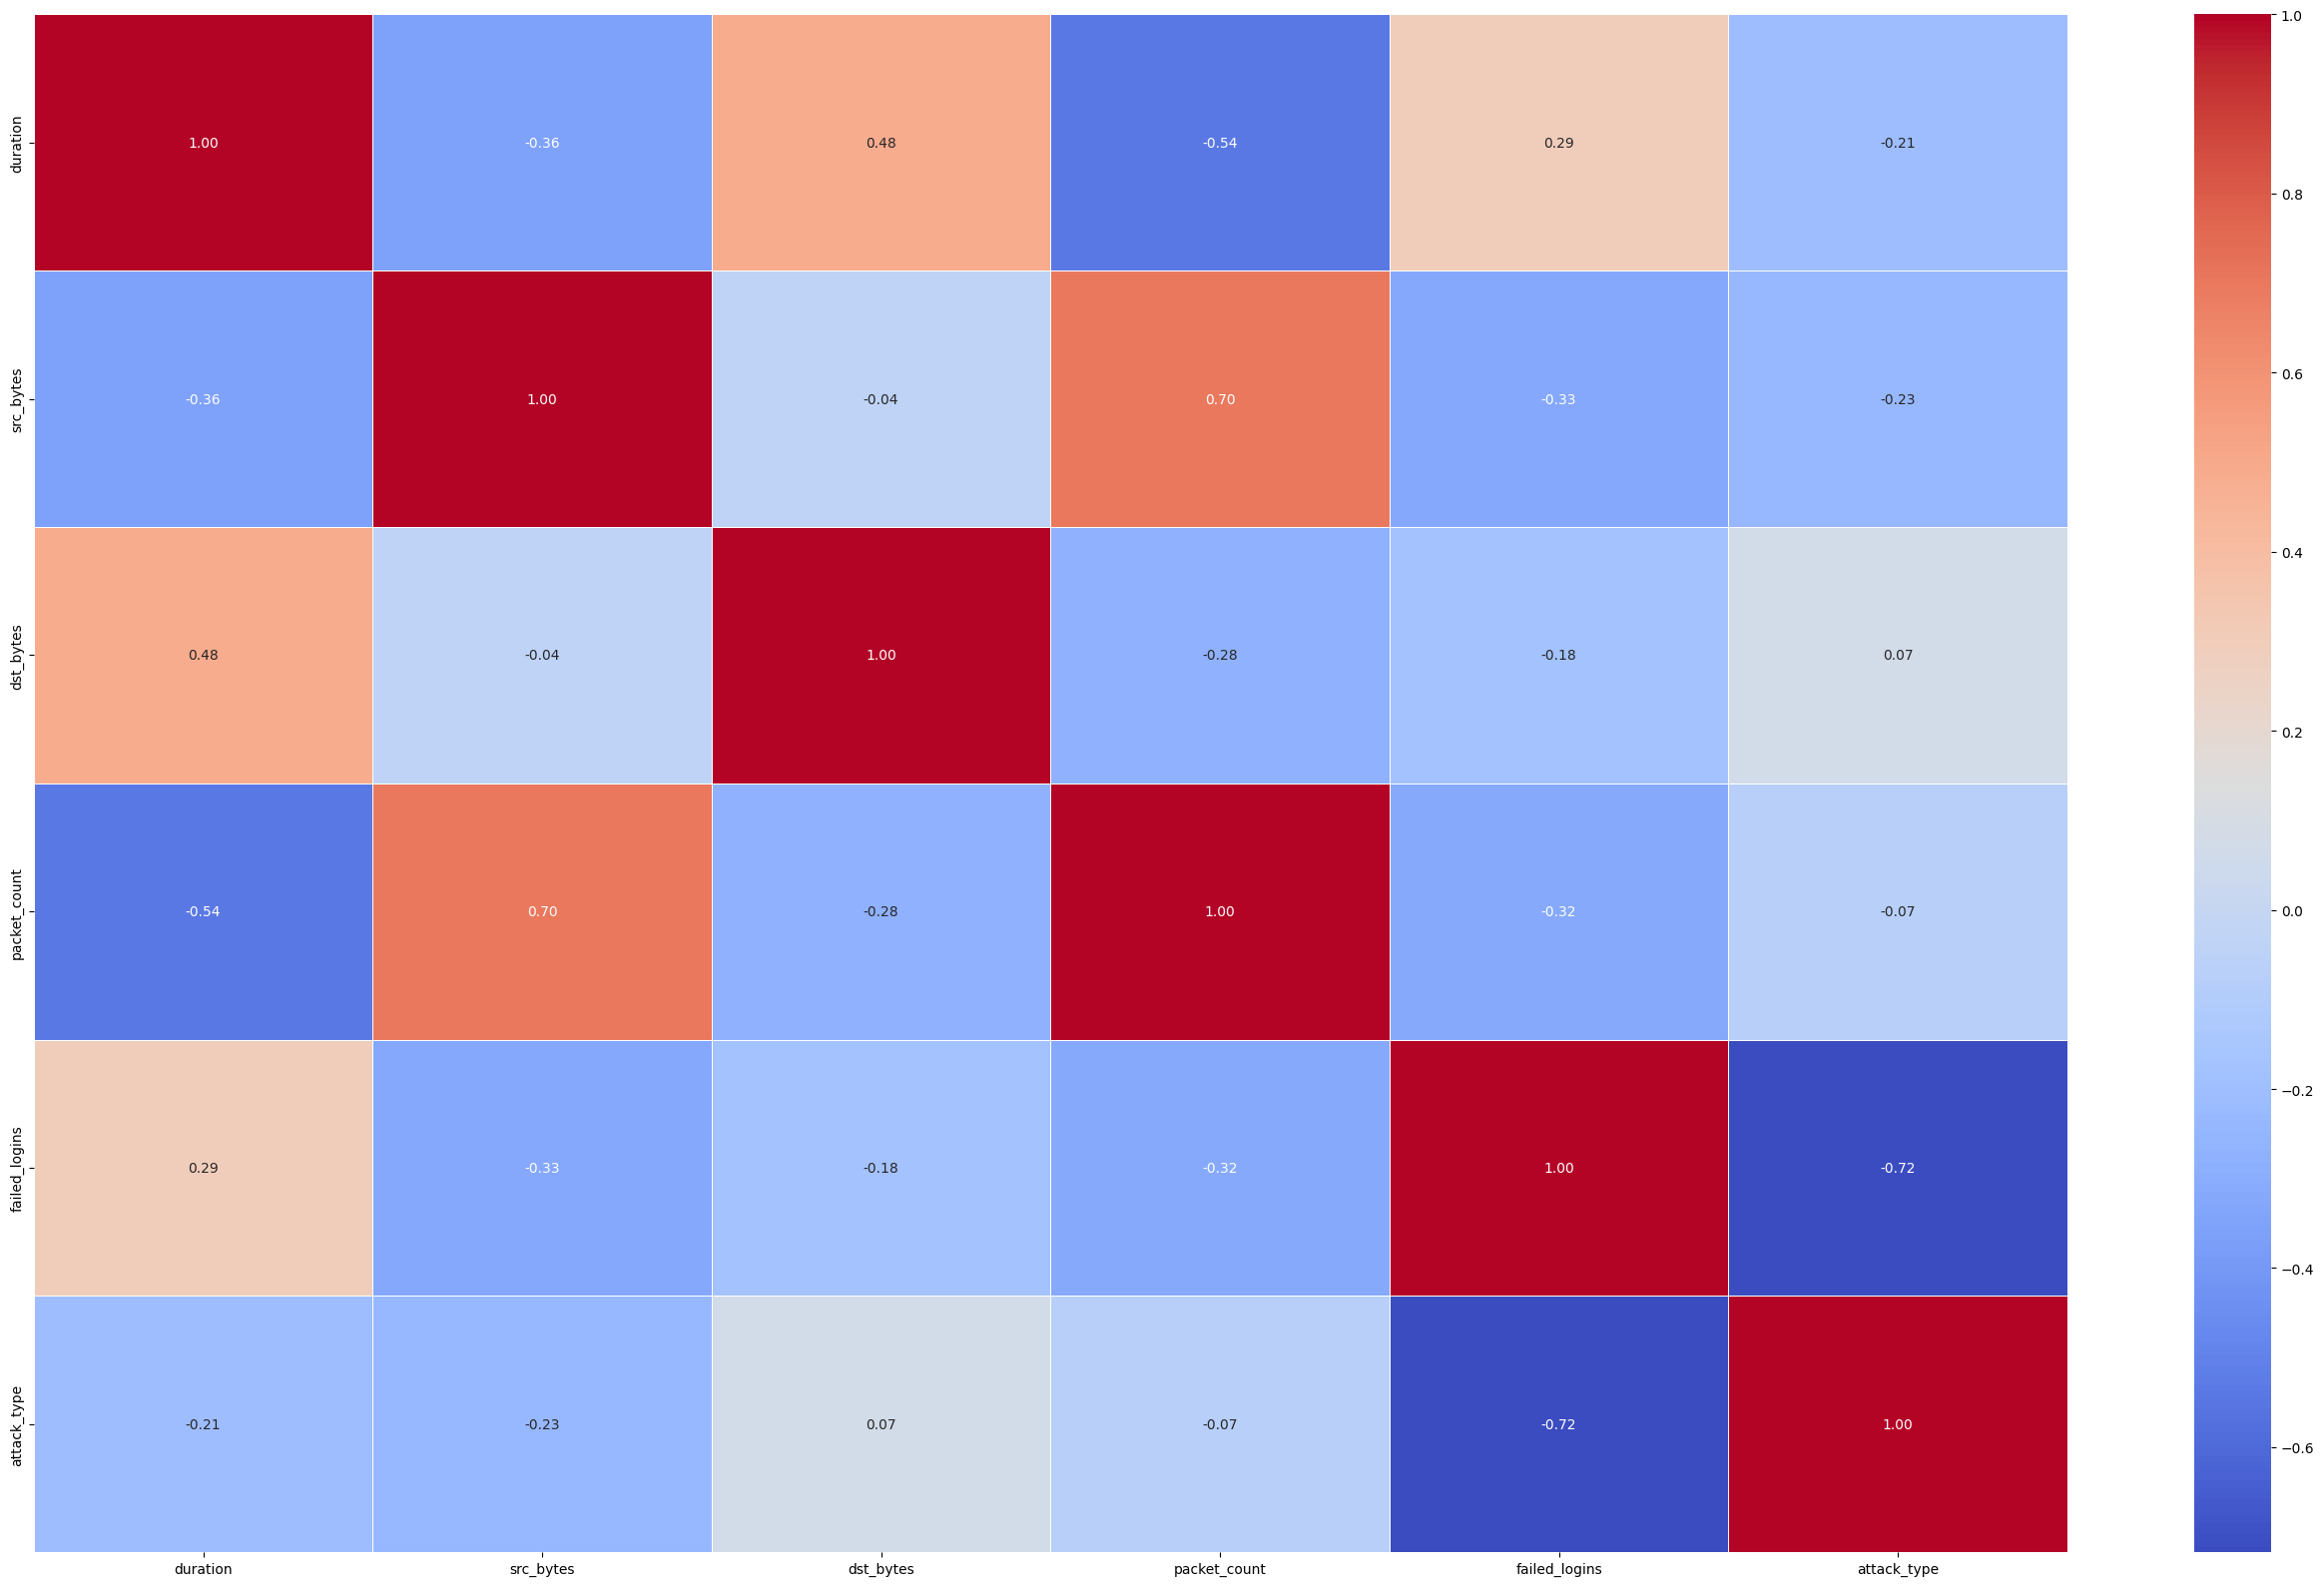

In [45]:
target_col ='attack_type'
plt.figure(figsize=(26,16))
corr_matrix = df[list(numerical_cols) + [target_col]].corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5)
plt.tight_layout()
plt.show()

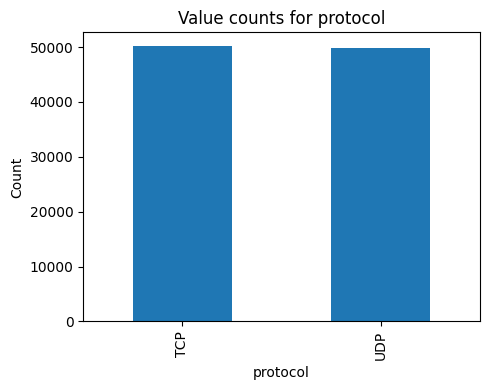

In [46]:
for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df[c].value_counts().plot(kind="bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

In [47]:
#numerical Pipeline
numerical_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

In [48]:
categorical_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehot',OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [49]:
#Combine numerical and categorical

from sklearn.compose import ColumnTransformer
Combine_pipe = ColumnTransformer([
    ('num',numerical_pipe,numerical_cols),
    ('cat',categorical_pipe,categorical_cols)
]
)

In [50]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size = 0.25 , random_state=42,stratify=y)

In [56]:
print(X_train.shape)
print(X_test.shape)

# duplicate check
import pandas as pd

train_df = pd.DataFrame(X_train)
test_df = pd.DataFrame(X_test)

duplicates = pd.merge(train_df, test_df, how='inner')
print("Duplicate samples:", len(duplicates))

(75000, 6)
(25000, 6)
Duplicate samples: 0


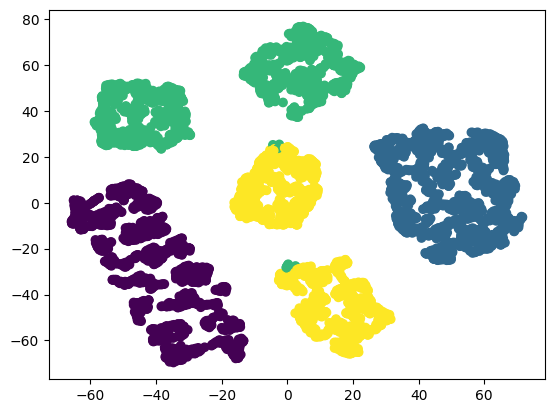

In [58]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X_processed = Combine_pipe.fit_transform(X)
X_embedded = TSNE(n_components=2).fit_transform(X_processed[:5000])

plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y[:5000])
plt.show()

In [51]:
# base Learner
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
xgb = XGBClassifier()

In [52]:
#voting Classification
voting_cls = VotingClassifier(
    estimators=[
        ('lr',lr),
        ('dt',dt),
        ('rf',rf),
        ('gb',gb),
        ('xgb',xgb)

    ],
    voting='soft'
)

In [53]:
#Stacking

stacking_cls = StackingClassifier(
    estimators=[
        ('lr',lr),
        ('dt',dt),
        ('rf',rf),
        ('gb',gb),
        ('xgb',xgb)
    ]
)

In [54]:
model_to_train = {    'Logistic Regression':lr,
    'Decision Tree':dt,
    'Random Forest':rf,
    'Gradient Boosting':gb,
    'XGBoost':xgb,
    'Voting Classifier':voting_cls,
    'Stacking Classifier':stacking_cls
}

In [55]:
# Train and Evaluate Models
results = []
for model_name, model in model_to_train.items():
  print(f"--- Training and Evaluating {model_name} ---")
  pipe = Pipeline(
      steps=[
          ('combine', Combine_pipe),
          ('model', model)
      ]
  )
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  report = classification_report(y_test, y_pred)
  cm = confusion_matrix(y_test, y_pred)

  results.append({
      'model_name': model_name,
      'accuracy': accuracy,
      'classification_report': report,
      'confusion_matrix': cm
  })
  print(f"Accuracy for {model_name}: {accuracy:.4f}")
  print(f"Classification Report for {model_name}:\n{report}")
  print(f"Confusion Matrix for {model_name}:\n{cm}\n")

print("\n--- All Model Results Summary ---")
for res in results:
    print(f"Model: {res['model_name']}, Accuracy: {res['accuracy']:.4f}")

--- Training and Evaluating Logistic Regression ---
Accuracy for Logistic Regression: 0.9996
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6260
           1       1.00      1.00      1.00      6269
           2       1.00      1.00      1.00      6219
           3       1.00      1.00      1.00      6252

    accuracy                           1.00     25000
   macro avg       1.00      1.00      1.00     25000
weighted avg       1.00      1.00      1.00     25000

Confusion Matrix for Logistic Regression:
[[6260    0    0    0]
 [   0 6269    0    0]
 [   0    0 6209   10]
 [   0    0    0 6252]]

--- Training and Evaluating Decision Tree ---
Accuracy for Decision Tree: 1.0000
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6260
           1       1.00      1.00      1.00      6269
    

The best performing model is Decision Tree with an accuracy of 1.0000


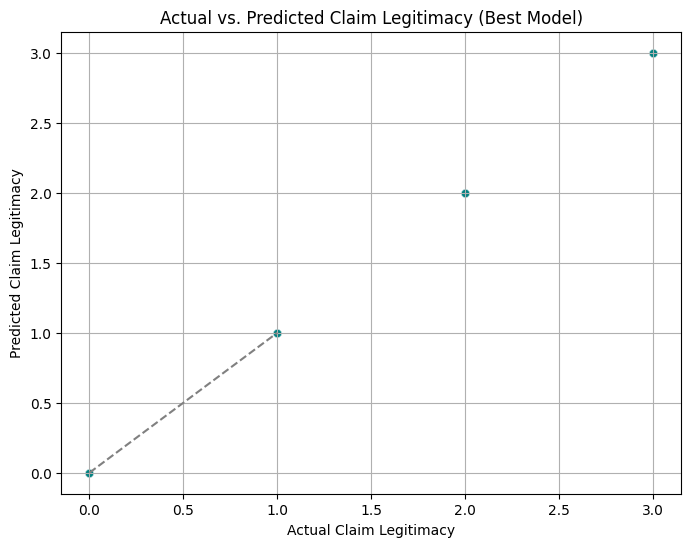

In [60]:
best_accuracy = -1
best_model_name = ''
best_model_obj = None

for res in results:
    if res['accuracy'] > best_accuracy:
        best_accuracy = res['accuracy']
        best_model_name = res['model_name']

best_model_obj = model_to_train[best_model_name]

print(f"The best performing model is {best_model_name} with an accuracy of {best_accuracy:.4f}")

#fit the best model
final_pipe = Pipeline([
    ('combine', Combine_pipe),
    ('model',best_model_obj)
])

final_pipe.fit(X_train,y_train)
y_final_pred = final_pipe.predict(X_test)


#plot Actual vs predicted
plt.figure( figsize = (8,6) )
sns.scatterplot(x=y_test, y=y_final_pred, alpha = 0.6, color='teal' )
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("Actual Claim Legitimacy")
plt.ylabel("Predicted Claim Legitimacy")
plt.title("Actual vs. Predicted Claim Legitimacy (Best Model)")
plt.grid(True)
plt.show()

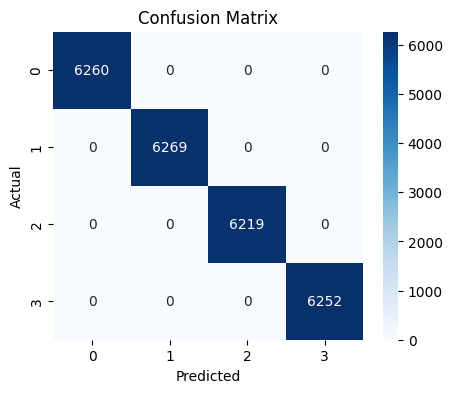

In [61]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [65]:
# Transform X_train before fitting the random forest classifier
X_train_transformed = Combine_pipe.transform(X_train)

# Fit the random forest classifier
rf.fit(X_train_transformed, y_train)

# Get the feature names after preprocessing by Combine_pipe
# Combine_pipe has been fit on the full X dataset in cell KCh4QicibaJo
# We can use get_feature_names_out() from the ColumnTransformer
transformed_feature_names = Combine_pipe.get_feature_names_out()

# Print feature importances with their transformed names
for feature, imp in zip(transformed_feature_names, rf.feature_importances_):
    print(feature, imp)

num__duration 0.16417622339361532
num__src_bytes 0.25436809927966947
num__dst_bytes 0.12952935072318034
num__packet_count 0.17904653952210775
num__failed_logins 0.2283596082058865
cat__protocol_TCP 0.018202195061355734
cat__protocol_UDP 0.026317983814184952


In [63]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

# Apply the preprocessing pipeline to X before cross-validation
X_processed_cv = Combine_pipe.fit_transform(X)

scores = cross_val_score(rf, X_processed_cv, y, cv=5)

print(scores)
print("Mean:", scores.mean())

[1.      0.99995 1.      1.      1.     ]
Mean: 0.99999


In [66]:
#voting Classification
voting_cls = VotingClassifier(
    estimators=[
        ('lr',lr),
        ('dt',dt),
        ('rf',rf),
        ('gb',gb),
        ('xgb',xgb)

    ],
    voting='soft'
)

model_lr = voting_cls
pipe_lr = Pipeline(
    steps=[
        ('combine', Combine_pipe),
        ('model', model_lr)
    ]
)
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6260
           1       1.00      1.00      1.00      6269
           2       1.00      1.00      1.00      6219
           3       1.00      1.00      1.00      6252

    accuracy                           1.00     25000
   macro avg       1.00      1.00      1.00     25000
weighted avg       1.00      1.00      1.00     25000



ROC AUC for Class 1: 1.000


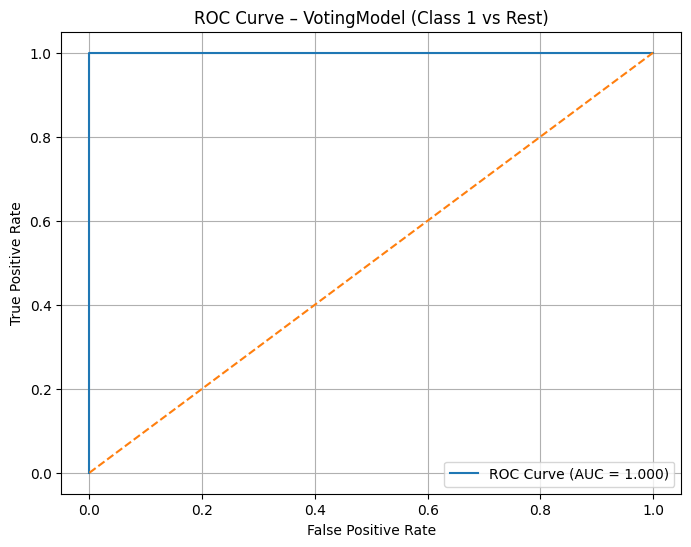

In [78]:
from sklearn.metrics import roc_curve, auc

# Get probabilities for all classes
y_prob_all_classes = pipe_lr.predict_proba(X_test)

# Select probabilities for class 1 (index 1)
y_prob_class_1 = y_prob_all_classes[:, 1]

# Binarize y_test for class 1 (1 if it's class 1, 0 otherwise)
y_test_binary_class_1 = (y_test == 1).astype(int)

# Calculate ROC curve and AUC for class 1
fpr, tpr, _ = roc_curve(y_test_binary_class_1, y_prob_class_1)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC for Class 1: {roc_auc:.3f}")

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – VotingModel (Class 1 vs Rest)")
plt.legend()
plt.grid(True)
plt.show()

In [72]:
param_grid = {'model__lr__solver': ['lbfgs', 'saga'],
              'model__lr__penalty': ['l2'],
              'model__lr__C': [0.01,0.1,1,10,100],
              'model__lr__max_iter': [1000,5000]
              }

In [73]:
from sklearn.model_selection import GridSearchCV

# Define the Logistic Regression Pipeline (lg_pipe)
# Assuming 'lr' is the LogisticRegression model defined earlier
lg_pipe = Pipeline(
    steps=[
        ('combine', Combine_pipe),
        ('model', lr)
    ]
)

# Define the parameter grid for GridSearchCV
param_grid = {
    'model__solver': ['liblinear', 'lbfgs'], # Solvers for logistic regression
    'model__C': [0.1, 1.0, 10.0] # Regularization strength
}

grid_search = GridSearchCV(
    estimator=lg_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [74]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('combine',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['duration', 'src_bytes', 'dst_bytes', 'packet_count', 'failed_logins'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['protocol'], dtype='object'))])),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1.0, 10.0],
                         'model__solver': ['liblinear', 'lbfgs']},
             scoring='accuracy', verbose=1)

In [75]:
print("Best Parameters Found:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters Found: {'model__C': 10.0, 'model__solver': 'lbfgs'}
Best CV Accuracy: 0.9996533333333334


In [76]:
best_lr_model = grid_search.best_estimator_

In [77]:
y_pred = best_lr_model.predict(X_test)
print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Final Test Accuracy: 0.9998
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6260
           1       1.00      1.00      1.00      6269
           2       1.00      1.00      1.00      6219
           3       1.00      1.00      1.00      6252

    accuracy                           1.00     25000
   macro avg       1.00      1.00      1.00     25000
weighted avg       1.00      1.00      1.00     25000



In [79]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21

In [80]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, classification_report

# Set experiment
mlflow.set_experiment("Cyber Attack")

# Define parameters for LogisticRegression
my_params = {
    'C': 1.0,
    'penalty': 'l2',
    'solver': 'lbfgs',
    'max_iter': 5000,
    'multi_class': 'multinomial',
    'random_state': 42
}

# Create a LogisticRegression instance with my_params
lr_configured_for_mlflow = LogisticRegression(**my_params)

# Re-define the VotingClassifier to include the configured LogisticRegression
# Use the other base learners (dt, rf, gb, xgb) which are globally defined
voting_cls_for_mlflow_run = VotingClassifier(
    estimators=[
        ('lr', lr_configured_for_mlflow), # Use the configured LR
        ('dt', dt),
        ('rf', rf),
        ('gb', gb),
        ('xgb', xgb)
    ],
    voting='soft'
)

# pipeline
simple_lr_pipe = Pipeline([
    ('combine', Combine_pipe),
    ('model', voting_cls_for_mlflow_run) # Pass the correctly constructed VotingClassifier
])

# Start MLflow run
with mlflow.start_run(run_name="Voting_Run"):

    mlflow.log_params(my_params)
    mlflow.log_param("model_type", "Voting")

    # Train model
    simple_lr_pipe.fit(X_train, y_train)
    # Prediction
    y_train_pred = simple_lr_pipe.predict(X_train)
    y_test_pred = simple_lr_pipe.predict(X_test)

    # Evaluate
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    mlflow.log_metric("train_accuracy", train_acc)
    mlflow.log_metric("test_accuracy", test_acc)

    # Log model
    mlflow.sklearn.log_model(simple_lr_pipe, "Voting_model")

    # Print results
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

2026/06/14 19:05:24 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/14 19:05:24 INFO mlflow.store.db.utils: Updating database tables
2026/06/14 19:05:27 INFO mlflow.tracking.fluent: Experiment with name 'Cyber Attack' does not exist. Creating a new experiment.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2026/06/14 19:06:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/14 19:06:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' forma

Train Accuracy: 1.0
Test Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6260
           1       1.00      1.00      1.00      6269
           2       1.00      1.00      1.00      6219
           3       1.00      1.00      1.00      6252

    accuracy                           1.00     25000
   macro avg       1.00      1.00      1.00     25000
weighted avg       1.00      1.00      1.00     25000

